In [1]:
# SOLO IN LOCALE
%load_ext autoreload
%autoreload 2

In [ ]:
# SOLO NELLA VERSIONE COLAB
# Prepare the notebook
!git clone --branch projectwork_25_26 https://github.com/ropinotex/network_optimization.git
import sys
sys.path.insert(0,'/content/network_optimization')

!pip install -r /content/network_optimization/requirements.txt

# Facility location problems examples #

In the following, some instructions about the solver are presented.

**The software is meant for didactic purposes only.**

*v2.0 - Last update: 2026-04-18*


Import the required data structures and functions.
Press shift + enter in each cell to run the commands, or click on Run in the command bar.

In [2]:
# Data structures and utilities
from data_structures import show_geo_map, show_data
from netopt_utils import plot_map, load_data_from_spreadsheet, get_data_from_loader

# Import the solver's user interface
from netopt_ui import netopt_ui


Problem data should be imported from an excel spreadsheet running the following two steps.

1) *Create a file loader*: this will give you the possibility to select the data source file from your computer. Run the next cell and then click on the button _Upload_ to select the data source. If everything is ok, the first few rows of each sheet will be displayed.

In [3]:
warehouses, customers = load_data_from_spreadsheet()


FileUpload(value=(), accept='.xlsx,.xls', description='Upload')

Output()

2) *Extract the data from the spreadsheet*: once the file is loaded, you should extract the data in two variables, _facilities_ for the candidates and _customers_ for the customers (you can choose your own variables' name)

In [8]:
# the argument of the following function is the output of the previous load_data_from_spreadsheet() function
# warehouses, customers = get_data_from_loader(file_loader)

NameError: name 'file_loader' is not defined

Check the content of the two variables:

In [4]:
warehouses


{0: Warehouse(name='F1', city='F1', state='', zipcode='', latitude=5, longitude=5, capacity=80, fixed_cost=123, unit_handling_cost=2),
 1: Warehouse(name='F2', city='F2', state='', zipcode='', latitude=5, longitude=5, capacity=80, fixed_cost=123, unit_handling_cost=1),
 2: Warehouse(name='F3', city='F3', state='', zipcode='', latitude=5, longitude=0, capacity=80, fixed_cost=123, unit_handling_cost=2),
 3: Warehouse(name='F4', city='F4', state='', zipcode='', latitude=5, longitude=10, capacity=80, fixed_cost=123, unit_handling_cost=2)}

In [5]:
customers

{0: Customer(name='C0', city='Paris', zipcode='', state='FR', latitude=0, longitude=0, demand=10),
 1: Customer(name='C1', city='Bordeaux', zipcode='', state='FR', latitude=10, longitude=0, demand=25),
 2: Customer(name='C2', city='Marseille', zipcode='', state='FR', latitude=0, longitude=10, demand=30),
 3: Customer(name='C3', city='Toulouse', zipcode='', state='FR', latitude=10, longitude=10, demand=20)}

You can change the problem data. However, pay attention and use the same format (columns name and order) in the provided spreadsheet.
If you change the date in the data source file, remember to A) save the file, and B) run both steps 1 and 2 above.


**Plot the data**

You can control the colors and shapes in the plot using the following parameters (also in the netopt function):
- warehouse_marker=shape of the warehouse icons. Allowed values are s=square, o=circle, *=star, ^=triangle, v=inverted triangle. Default is s 
- warehouse_markercolor=color of the warehouse icons. Allowed values are red, green, blue, black, yellow. Default is red
- warehouse_markersize=size of the warehouse icons. Default is 4
- warehouse_active_markersize=size of the warehouse icons representing active (open) warehouses. Default is 5
- customer_marker=shape of the customer icons. Default is o
- customer_markercolor=color of the customer icons. Default is blue
- customer_markersize=size of the customer icons. Default is 4

If you don't specify the above parameters about the figures, the default values will be assumed

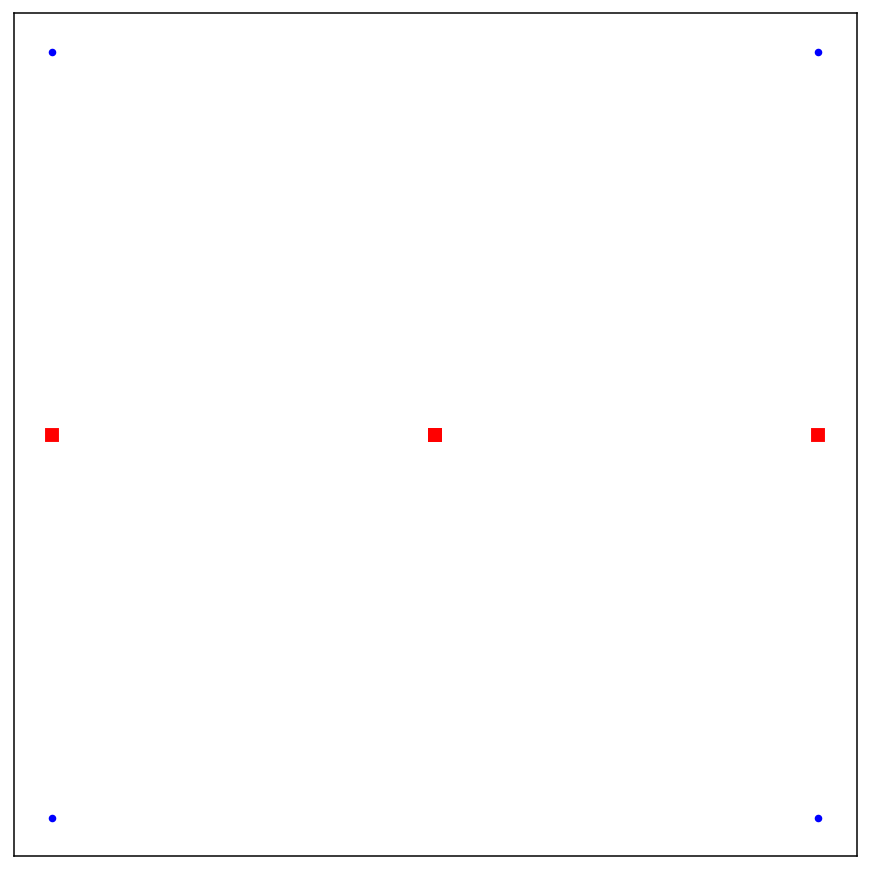

In [6]:
plot_map(customers=customers,
         warehouses=warehouses,
         warehouse_marker='s',
         warehouse_markercolor='red',
         warehouse_markersize=6,
         customer_marker='o',
         customer_markercolor='blue',
         customer_markersize=3)

A better map can be shown using the following command. However, this map allows only for the
visualization of location. To show the connections in the final solution you should use the plot_map command

In [5]:
show_geo_map(customers=customers, warehouses=warehouses, zoom=6)

Launch the solver's user interface

In [7]:
results = netopt_ui(warehouses, customers)

No distance matrix provided, calculating from coordinates... done!


Button(button_style='success', description='Solve', style=ButtonStyle())

Output()

The results variable contains a summary of the optimization report

For a slightly better visualization of the results use print_solution as follows

In [8]:
results.result

{'status': 'Optimal',
 'objective_value': 2.0,
 'avg_weighted_distance': np.float64(5.0),
 'active_warehouses_id': {2, 3},
 'active_warehouses_name': ['F3', 'F4'],
 'most_distant_customer': np.float64(5.0),
 'demand_perc_by_ranges': {(0, 99999): 1.0},
 'avg_customer_distance': np.float64(5.0),
 'std_customer_distance': np.float64(0.0),
 'p25_customer_distance': 5.0,
 'p50_customer_distance': 5.0,
 'p75_customer_distance': 5.0,
 'p25_customer_distance_unweighted': np.float64(5.0),
 'p50_customer_distance_unweighted': np.float64(5.0),
 'p75_customer_distance_unweighted': np.float64(5.0),
 'multi_sourced_customers': [],
 'customers_assignment': [{'Warehouse': 'F4',
   'Warehouse_id': 3,
   'Customer': 'Marseille',
   'Customer_id': 2,
   'Customer Demand': 30,
   'Distance': 5.0,
   'Warehouse Latitude': 5,
   'Warehouse Longitude': 10,
   'Customers Latitude': 0,
   'Customers Longitude': 10,
   'Flow': 30.0},
  {'Warehouse': 'F4',
   'Warehouse_id': 3,
   'Customer': 'Toulouse',
   'Cus

In [10]:
warehouses

{0: Warehouse(name='F1', city='Paris', state='', zipcode='', latitude=48.853, longitude=2.349, capacity=35000, fixed_cost=1000),
 1: Warehouse(name='F2', city='Marseille', state='', zipcode='', latitude=43.297, longitude=5.381, capacity=15000, fixed_cost=1000),
 2: Warehouse(name='F3', city='Lyon', state='', zipcode='', latitude=45.748, longitude=4.847, capacity=14000, fixed_cost=1000),
 3: Warehouse(name='F4', city='Toulouse', state='', zipcode='', latitude=43.604, longitude=1.444, capacity=9000, fixed_cost=1000),
 4: Warehouse(name='F5', city='Nice', state='', zipcode='', latitude=43.703, longitude=7.266, capacity=9000, fixed_cost=1000),
 5: Warehouse(name='F6', city='Nantes', state='', zipcode='', latitude=47.217, longitude=-1.553, capacity=20000, fixed_cost=1000),
 6: Warehouse(name='F7', city='Strasbourg', state='', zipcode='', latitude=48.584, longitude=7.746, capacity=9000, fixed_cost=1000),
 7: Warehouse(name='F8', city='Bordeaux', state='', zipcode='', latitude=44.84, longitud